In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [8]:
file = open("timeseries_all_labelled_train_test_labels.csv")
y = np. loadtxt(file, delimiter=",")
print(y)

[ 0.  0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  2.  2.  2.  2.  2.  2.  2.  2.  2.  2.  3.  3.  3.  3.  3.  3.
  3.  3.  3.  3.  4.  4.  4.  4.  4.  4.  4.  4.  4.  4.  5.  5.  5.  5.
  5.  5.  5.  5.  5.  5.  6.  6.  6.  6.  6.  6.  6.  6.  6.  6.  7.  7.
  7.  7.  7.  7.  7.  7.  7.  8.  8.  8.  8.  8.  8.  8.  8.  8.  8.  9.
  9.  9.  9.  9.  9.  9.  9.  9.  9. 10. 10. 10. 10. 10. 10. 10. 10. 10.
 10. 11. 11. 11. 11. 11. 11. 11. 11. 11. 11.]


In [9]:
file = open("timeseries_all_labelled_train_test_frames.csv")
x = np. loadtxt(file, delimiter=",")
print(x)

[[ 7.  7.  7. ...  7.  7.  7.]
 [11. 11. 11. ...  7. 11.  7.]
 [ 7.  7.  7. ... 10. 10. 10.]
 ...
 [11. 11. 11. ...  7.  7.  7.]
 [ 7.  7.  7. ... 11. 11. 11.]
 [11. 11. 11. ...  7.  7.  7.]]


In [10]:
X_train, X_test, y_train, y_test = train_test_split(x, y)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(89, 1023) (89,) (30, 1023) (30,)


In [11]:
from sktime.classification.distance_based import KNeighborsTimeSeriesClassifier

knn = KNeighborsTimeSeriesClassifier(n_neighbors=1, distance="dtw")
knn.fit(X_train, y_train)
knn.score(X_test, y_test)

0.06666666666666667

In [12]:
import seaborn as sns
import warnings
warnings.simplefilter("ignore")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix

In [13]:
classifier = knn

In [14]:
novel = open("timeseries_novel_output_frames.csv")
novel_frames = np. loadtxt(novel, delimiter=",")
print(novel_frames)

[[10. 10. 10. ... 10. 10. 10.]
 [11. 11. 11. ...  7.  7.  7.]
 [11. 11. 11. ... 11. 11. 11.]
 ...
 [ 8.  8.  8. ...  8.  8.  8.]
 [11. 11. 11. ...  8.  8.  8.]
 [ 7.  7.  7. ...  7.  7.  7.]]


In [15]:
y_pred= classifier.predict(novel_frames)

In [16]:
novel_labels = open("timeseries_novel_output_labels.csv")
novel_labels = np. loadtxt(novel_labels, delimiter=",")
print(novel_labels)

[0. 0. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 2. 2. 3. 3. 3. 3. 4. 4. 5. 6. 8. 8.
 8. 8. 8. 8. 8. 8. 8. 8. 8.]


In [11]:
confusion_matrix(novel_labels,y_pred)

array([[1, 0, 3, 0, 0, 2, 1, 0, 0, 0, 0, 1],
       [0, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1],
       [0, 0, 0, 1, 0, 0, 0, 1, 0, 2, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 2, 3, 0, 0, 0, 0, 1, 1, 0, 3],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]])

Confusion matrix, without normalization
[[1 0 3 0 0 2 1 0 0 0 1 0]
 [0 0 2 1 0 0 0 0 0 0 0 1]
 [0 0 0 0 0 0 0 1 0 0 0 1]
 [0 0 0 0 0 1 0 1 0 2 0 0]
 [0 0 0 0 0 0 0 0 0 1 0 1]
 [0 0 0 0 0 0 0 0 0 0 1 0]
 [0 0 0 0 0 0 0 0 1 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 1 1 2 1 0 0 0 4 1 0 1]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]
 [0 0 0 0 0 0 0 0 0 0 0 0]]
Normalized confusion matrix
[[0.125      0.         0.375      0.         0.         0.25
  0.125      0.         0.         0.         0.125      0.        ]
 [0.         0.         0.5        0.25       0.         0.
  0.         0.         0.         0.         0.         0.25      ]
 [0.         0.         0.         0.         0.         0.
  0.         0.5        0.         0.         0.         0.5       ]
 [0.         0.         0.         0.         0.         0.25
  0.         0.25       0.         0.5        0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0. 

NameError: name 'savefig' is not defined

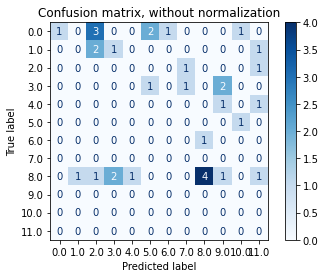

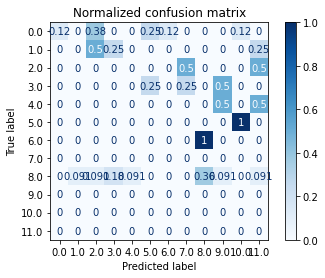

In [21]:
from sklearn.metrics import ConfusionMatrixDisplay
from matplotlib import pyplot as plt
# Plot non-normalized confusion matrix
titles_options = [
    ("Confusion matrix, without normalization", None),
    ("Normalized confusion matrix", "true"),
]
for title, normalize in titles_options:
    disp = ConfusionMatrixDisplay.from_estimator(
        classifier,
        novel_frames,
        novel_labels,
        #display_labels=class_names,
        cmap=plt.cm.Blues,
        normalize=normalize,
    )
    disp.ax_.set_title(title)

    print(title)
    print(disp.confusion_matrix)